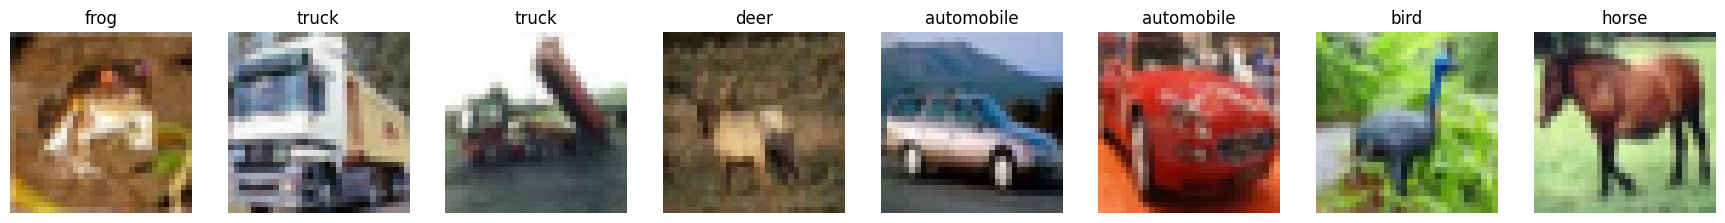

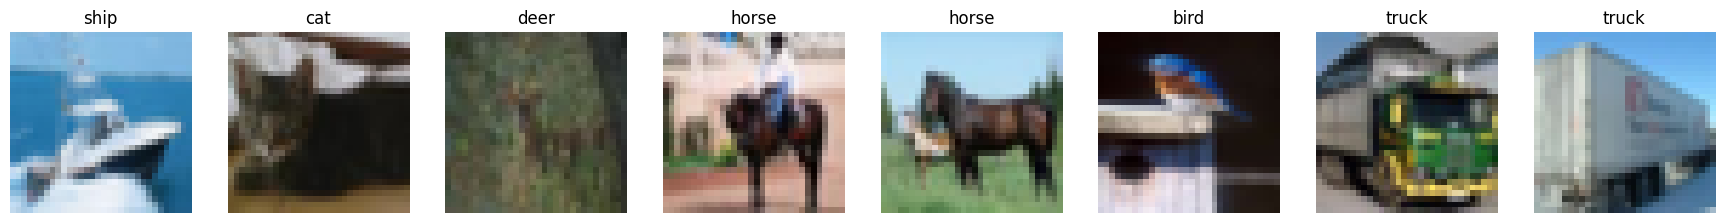

In [30]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import cv2

def show_images(images, labels, ncols=8):
    figure, axs = plt.subplots(figsize=(22, 6), nrows=1, ncols=ncols)
    for i in range(ncols):
        # PyTorch 텐서를 numpy로 변환하고 채널 순서를 변경 (C, H, W) -> (H, W, C)
        img = images[i].permute(1, 2, 0)
        # 정규화 해제 ([-1, 1] -> [0, 1])
        img = img * 0.5 + 0.5
        img = torch.clamp(img, 0, 1) # 0 ~ 1 범위로 값 clamp
        axs[i].imshow(img.cpu().numpy())

        # 라벨 처리
        if torch.is_tensor(labels[i]):
            label = labels[i].item()
        else:
            label = labels[i]
        axs[i].set_title(class_names[int(label)])
        axs[i].axis('off')

    plt.show()

# 시각화를 위한 데이터 가져오기
vis_loader = DataLoader(trainset, batch_size=16, shuffle=False)
vis_images, vis_labels = next(iter(vis_loader))

show_images(vis_images[:8], vis_labels[:8], ncols=8)
show_images(vis_images[8:16], vis_labels[8:16], ncols=8)

In [31]:
class CIFAR10_CNN(nn.Module):
    def __init__(self, num_classes=10):
        super(CIFAR10_CNN, self).__init__()

        # 첫 번째 컨볼루션 블록
        self.conv1_1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv1_2 = nn.Conv2d(32, 32, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        # 두 번째 컨볼루션 블록
        self.conv2_1 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv2_2 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        # 세 번째 컨볼루션 블록
        self.conv3_1 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.conv3_2 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)

        # 완전 연결 레이어
        self.flatten = nn.Flatten()
        self.dropout1 = nn.Dropout(0.5)
        self.fc1 = nn.Linear(128 * 4 * 4, 300)  # 4x4는 32x32 이미지가 3번의 pooling을 거쳐서 나온 크기
        self.dropout2 = nn.Dropout(0.3)
        self.fc2 = nn.Linear(300, num_classes)

    def forward(self, x):
        # 첫 번째 컨볼루션 블록
        x = F.relu(self.conv1_1(x))
        x = F.relu(self.conv1_2(x))
        x = self.pool1(x)

        # 두 번째 컨볼루션 블록
        x = F.relu(self.conv2_1(x))
        x = F.relu(self.conv2_2(x))
        x = self.pool2(x)

        # 세 번째 컨볼루션 블록
        x = F.relu(self.conv3_1(x))
        x = F.relu(self.conv3_2(x))
        x = self.pool3(x)

        # 완전 연결 레이어
        x = self.flatten(x)
        x = self.dropout1(x)
        x = F.relu(self.fc1(x))
        x = self.dropout2(x)
        x = self.fc2(x)  # CrossEntropyLoss에서 softmax가 자동으로 적용됨

        return x

# 모델 생성
model = CIFAR10_CNN(num_classes=10)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

# 모델 구조 출력
print(model)

CIFAR10_CNN(
  (conv1_1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv1_2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2_1): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2_2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3_1): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3_2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (dropout1): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=2048, out_features=300, bias=True)
  (dropout2): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=300, out_features=10, bias=T

In [32]:
from torchsummary import summary
summary(model, (3, 32, 32))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 32, 32]             896
            Conv2d-2           [-1, 32, 32, 32]           9,248
         MaxPool2d-3           [-1, 32, 16, 16]               0
            Conv2d-4           [-1, 64, 16, 16]          18,496
            Conv2d-5           [-1, 64, 16, 16]          36,928
         MaxPool2d-6             [-1, 64, 8, 8]               0
            Conv2d-7            [-1, 128, 8, 8]          73,856
            Conv2d-8            [-1, 128, 8, 8]         147,584
         MaxPool2d-9            [-1, 128, 4, 4]               0
          Flatten-10                 [-1, 2048]               0
          Dropout-11                 [-1, 2048]               0
           Linear-12                  [-1, 300]         614,700
          Dropout-13                  [-1, 300]               0
           Linear-14                   

In [33]:
from torch.optim.lr_scheduler import ReduceLROnPlateau
import torch.optim as optim

# optimizer는 Adam으로 설정하고, label값이 원-핫 인코딩이 아니므로 loss는 CrossEntropyLoss 임.
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 학습률 스케줄러 설정 (선택사항)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)


# 검증 데이터셋 생성 (train 데이터의 15%를 검증용으로 사용)
train_size = int(0.85 * len(trainset))
val_size = len(trainset) - train_size
train_dataset, val_dataset = random_split(trainset, [train_size, val_size])

# 데이터 로더 생성
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

print(f"학습 데이터 크기: {len(train_dataset)}")
print(f"검증 데이터 크기: {len(val_dataset)}")
print(f"테스트 데이터 크기: {len(testset)}")

# 학습 함수 정의
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs=30, patience=5):
    train_losses = []
    train_accuracies = []
    val_losses = []
    val_accuracies = []

    best_val_loss = float('inf')
    patience_counter = 0

    for epoch in range(num_epochs):
        # 학습 모드
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0

        for batch_idx, (data, target) in enumerate(train_loader):
            data, target = data.to(device), target.to(device)

            optimizer.zero_grad()
            outputs = model(data)
            loss = criterion(outputs, target)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            train_total += target.size(0)
            train_correct += (predicted == target).sum().item()

        # 검증 모드
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for data, target in val_loader:
                data, target = data.to(device), target.to(device)
                outputs = model(data)
                loss = criterion(outputs, target)

                val_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                val_total += target.size(0)
                val_correct += (predicted == target).sum().item()

        # 평균 계산
        train_loss = train_loss / len(train_loader)
        val_loss = val_loss / len(val_loader)
        train_acc = train_correct / train_total
        val_acc = val_correct / val_total

        train_losses.append(train_loss)
        train_accuracies.append(train_acc)
        val_losses.append(val_loss)
        val_accuracies.append(val_acc)

        print(f'Epoch {epoch+1}/{num_epochs}:')
        print(f'  Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}')
        print(f'  Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}')

        # 학습률 스케줄러 업데이트
        scheduler.step(val_loss)

        # 조기 종료 체크
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            # 최고 모델 저장
            torch.save(model.state_dict(), 'cifar10_best_model.pth')
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print(f'Early stopping at epoch {epoch+1}')
            break

    # 최고 모델 로드
    model.load_state_dict(torch.load('cifar10_best_model.pth'))

    return {
        'train_loss': train_losses,
        'train_accuracy': train_accuracies,
        'val_loss': val_losses,
        'val_accuracy': val_accuracies
    }

# 학습 실행
history = train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs=30, patience=5)

학습 데이터 크기: 42500
검증 데이터 크기: 7500
테스트 데이터 크기: 10000
Epoch 1/30:
  Train Loss: 1.6774, Train Acc: 0.3680
  Val Loss: 1.2995, Val Acc: 0.5283
Epoch 2/30:
  Train Loss: 1.2218, Train Acc: 0.5563
  Val Loss: 1.2592, Val Acc: 0.5649
Epoch 3/30:
  Train Loss: 1.0407, Train Acc: 0.6281
  Val Loss: 0.9565, Val Acc: 0.6615
Epoch 4/30:
  Train Loss: 0.9228, Train Acc: 0.6735
  Val Loss: 0.8877, Val Acc: 0.6777
Epoch 5/30:
  Train Loss: 0.8285, Train Acc: 0.7060
  Val Loss: 0.8368, Val Acc: 0.7016
Epoch 6/30:
  Train Loss: 0.7611, Train Acc: 0.7319
  Val Loss: 0.7701, Val Acc: 0.7284
Epoch 7/30:
  Train Loss: 0.7039, Train Acc: 0.7514
  Val Loss: 0.7368, Val Acc: 0.7441
Epoch 8/30:
  Train Loss: 0.6525, Train Acc: 0.7727
  Val Loss: 0.7020, Val Acc: 0.7532
Epoch 9/30:
  Train Loss: 0.6201, Train Acc: 0.7818
  Val Loss: 0.7075, Val Acc: 0.7565
Epoch 10/30:
  Train Loss: 0.5848, Train Acc: 0.7931
  Val Loss: 0.7184, Val Acc: 0.7489
Epoch 11/30:
  Train Loss: 0.5538, Train Acc: 0.8055
  Val Loss: 0.7

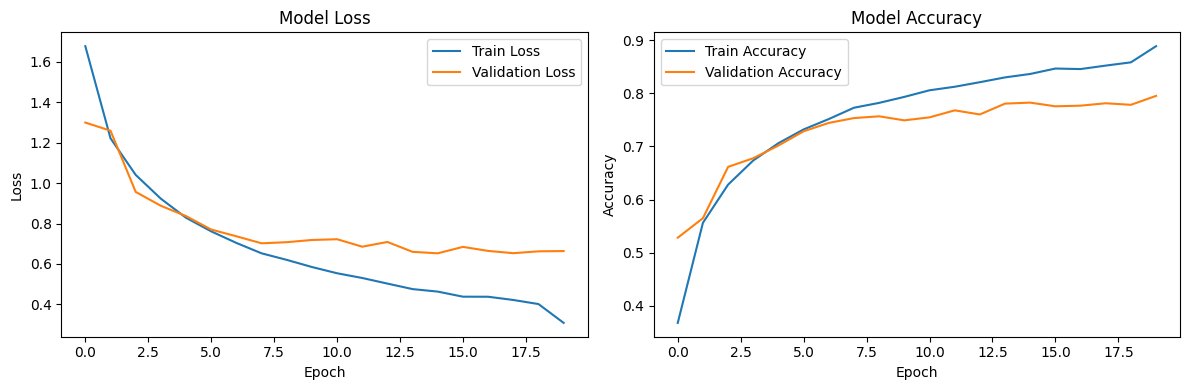

In [34]:
import matplotlib.pyplot as plt

def show_history(history):
    plt.figure(figsize=(12, 4))

    # 손실 그래프
    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'], label='Train Loss')
    plt.plot(history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    # 정확도 그래프
    plt.subplot(1, 2, 2)
    plt.plot(history['train_accuracy'], label='Train Accuracy')
    plt.plot(history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.show()

show_history(history)

In [35]:
# 테스트 데이터로 성능 평가
def evaluate_model(model, test_loader):
    model.eval()
    test_loss = 0.0
    test_correct = 0
    test_total = 0

    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            outputs = model(data)
            loss = criterion(outputs, target)

            test_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            test_total += target.size(0)
            test_correct += (predicted == target).sum().item()

    test_loss = test_loss / len(test_loader)
    test_acc = test_correct / test_total

    return test_loss, test_acc

# 테스트 데이터로 평가
test_loss, test_acc = evaluate_model(model, test_loader)
print(f'Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.4f}')


Test Loss: 0.6541, Test Accuracy: 0.7830
